<a href="https://colab.research.google.com/github/akashmavle5/--akash/blob/main/Notebook10_Integrated_Educational_MCAIXI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 10 — Integrated Educational MC-AIXI Architecture

This notebook combines ideas from the previous notebooks into one modular
educational agent.

Included:

- Bayesian hypothesis mixture
- Context-based prediction
- World model
- Monte Carlo planning
- Multi-environment evaluation
- Simple metrics dashboard

**Note:** This is an educational architecture inspired by MC-AIXI ideas, not
the original MC-AIXI-CTW algorithm.


In [10]:
import random, math
import numpy as np
import matplotlib.pyplot as plt

random.seed(2026)
np.random.seed(2026)


In [11]:
class BanditEnv:
    def __init__(self):
        self.p=[0.2,0.5,0.8]
    def reset(self): return 0
    def step(self,a):
        return 0,1 if random.random()<self.p[a] else 0,False

class GridEnv:
    ACTIONS=["U","D","L","R"]
    def __init__(self,n=5):
        self.n=n
        self.goal=(n-1,n-1)
        self.reset()
    def reset(self):
        self.s=(0,0)
        return self.s
    def clone(self):
        g=GridEnv(self.n)
        g.goal=self.goal
        g.s=self.s
        return g
    def step(self,a):
        x,y=self.s
        if a==0:x=max(0,x-1)
        elif a==1:x=min(self.n-1,x+1)
        elif a==2:y=max(0,y-1)
        else:y=min(self.n-1,y+1)
        self.s=(x,y)
        r=-1; done=False
        if self.s==self.goal:
            r=25; done=True
        return self.s,r,done


In [12]:
class BayesianMixture:
    def __init__(self):
        self.bias=np.array([0.8,1.0,1.2,1.5])
        prior=np.array([2**-1,2**-2,2**-2,2**-3],float)
        self.post=prior/prior.sum()
    def update(self,r):
        like=np.exp(-np.abs(r-self.bias*np.maximum(r,0.1)))
        self.post*=like+1e-9
        self.post/=self.post.sum()
    def expected(self,x):
        return float(np.dot(self.post,self.bias*x))

class ContextPredictor:
    def __init__(self,k=3):
        self.k=k
        self.db={}
    def update(self,h,s):
        key=tuple(h[-self.k:])
        self.db.setdefault(key,[1,1])[s]+=1
    def predict(self,h):
        c=self.db.get(tuple(h[-self.k:]),[1,1])
        t=sum(c)
        return c[0]/t,c[1]/t

class WorldModel:
    def __init__(self):
        self.t={}
        self.r={}
    def update(self,s,a,s2,r):
        self.t[(s,a)]=s2
        self.r[(s,a)]=r
    def predict(self,s,a):
        return self.t.get((s,a),s),self.r.get((s,a),-1)


In [13]:
def rollout(env,d=6,gamma=0.95):
    w=env.clone()
    total=0
    for i in range(d):
        _,r,done=w.step(random.randint(0,3))
        total+=(gamma**i)*r
        if done: break
    return total

def choose(env,iters=30):
    vals=[]
    for a in range(4):
        scores=[]
        for _ in range(iters):
            w=env.clone()
            _,r,done=w.step(a)
            v=r if done else r+rollout(w)
            scores.append(v)
        vals.append(np.mean(scores))
    return int(np.argmax(vals)),vals


In [14]:
class EducationalMCAIXI:
    def __init__(self):
        self.mix=BayesianMixture()
        self.ctx=ContextPredictor()
        self.model=WorldModel()
        self.hist=[]
    def observe(self,s,a,s2,r):
        self.mix.update(r)
        self.ctx.update(self.hist,1 if r>0 else 0)
        self.model.update(s,a,s2,r)
        self.hist.append(1 if r>0 else 0)


## GridWorld Evaluation

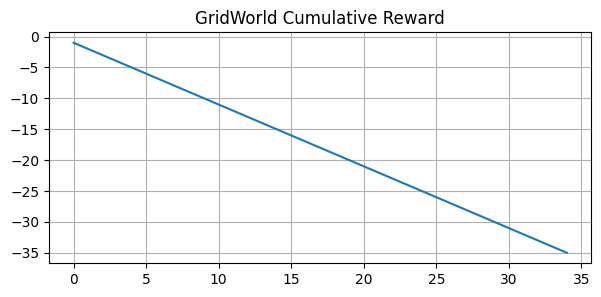

In [15]:
env=GridEnv()
agent=EducationalMCAIXI()

state=env.reset()
cum=[]
total=0

for step in range(35):
    action,vals=choose(env)
    old=state
    state,r,done=env.step(action)
    agent.observe(old,action,state,r)
    total+=r
    cum.append(total)
    if done:
        break

plt.figure(figsize=(7,3))
plt.plot(cum)
plt.grid()
plt.title("GridWorld Cumulative Reward")
plt.show()


## Bandit Evaluation

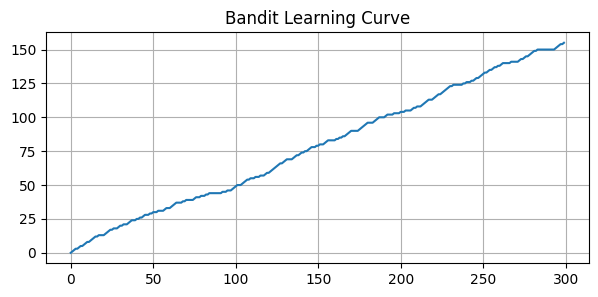

In [16]:
bandit=BanditEnv()
agent2=EducationalMCAIXI()
rewards=[]; total=0

for _ in range(300):
    arm=random.randint(0,2)
    _,r,_=bandit.step(arm)
    total+=r
    agent2.observe(0,arm,0,r)
    rewards.append(total)

plt.figure(figsize=(7,3))
plt.plot(rewards)
plt.grid()
plt.title("Bandit Learning Curve")
plt.show()


## Learned Beliefs

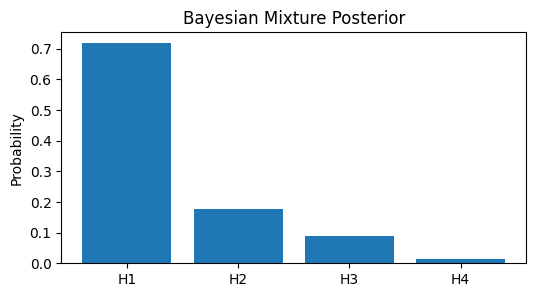

Context predictor:
P(non-reward) = 0.971
P(reward)     = 0.029
Known world-model transitions: 1


In [17]:
plt.figure(figsize=(6,3))
plt.bar(["H1","H2","H3","H4"],agent.mix.post)
plt.title("Bayesian Mixture Posterior")
plt.ylabel("Probability")
plt.show()

p0,p1=agent.ctx.predict(agent.hist)
print("Context predictor:")
print("P(non-reward) =",round(p0,3))
print("P(reward)     =",round(p1,3))
print("Known world-model transitions:",len(agent.model.t))


## Simple Metrics

In [18]:
metrics={
"Grid cumulative reward": cum[-1] if cum else 0,
"Bandit cumulative reward": rewards[-1],
"Posterior entropy": float(-(agent.mix.post*np.log2(agent.mix.post+1e-12)).sum()),
"World-model size": len(agent.model.t),
"Context states": len(agent.ctx.db)
}
metrics


{'Grid cumulative reward': -35,
 'Bandit cumulative reward': 155,
 'Posterior entropy': 1.1895333912274415,
 'World-model size': 1,
 'Context states': 4}

# Final Summary

Across ten notebooks you have implemented educational versions of many concepts
associated with Universal Artificial Intelligence:

| Concept | Notebook |
|---|---|
| Bayesian inference | 1 |
| Occam prior | 1 |
| Solomonoff-inspired mixtures | 2, 9 |
| Planning | 3 |
| Context prediction | 4, 7 |
| Educational MC-AIXI agent | 5 |
| World models | 6 |
| Monte Carlo Tree Search | 8 |
| Program induction | 9 |
| Integrated architecture | 10 |

This project is intended as a teaching aid. Exact AIXI and MC-AIXI-CTW remain
significantly more sophisticated and include components that cannot be computed
exactly in finite time.
